# Fractional Brownian Motion Parameter Estimation Using Periodogram Method

The periodigram method uses the fractional brownian noise power spectrum to estimate the Hurst, denoted by $H$. The power spectrum is the Fourier transform of the fractional brownian motion noise autocorrelation function. This relationship is called the Weiner-Khichnin theorem.</br>

Let $Z^H(t)$ denote a fractional path then fractional brownian noise is defined by,

$
\begin{align}
\Delta Z_k^H = Z^H(t_k) - Z^H(t_{k-1})
\end{align}
\tag{1}
$

where $t_k = k \Delta t$. It follows that,

$
\begin{align}
Z^H(n\Delta t) = \sum_{i=1}^n \Delta Z_k^H
\end{align}
\tag{2}
$

The autocovariance of fractional brownian noise is given by,

$
\begin{align}
\gamma^H_n = \text{Cov}[\Delta Z^H_t \Delta Z^H_{t+n}] = \frac{1}{2}\Delta t^{2H}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{3}
$

Since $\text{Var}(\Delta Z_k^H) = \Delta t^{2H}$ the autocorrelation coefficient is defined by,</br>

$
\begin{align}
\rho^H_n = \frac{\gamma^H_n}{\Delta t^{2H}} = \frac{1}{2}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

From the Weiner-Khichnin theorem the power spectrum is given by,</br>

$
\begin{align}
\hat{\rho}^H_\omega = \frac{1}{2} \int_{-\infty}^{\infty} \rho^H_n e^{-i \omega n} dn
\end{align}
\tag{5}
$

It can be shown that fir $\omega \gg 1$,

$
\begin{align}
\hat{\rho}^H_\omega \approx C\lvert \omega \rvert^{1 - 2H}
\end{align}
\tag{6}
$

where $C$ is independent of $\omega$. It follows that $H$ can be determined by using OLS on $\hat{\rho}^H_\omega$ as a< function of $\omega$.

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import periodogram, curve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
npts = 2**10

## Power Spectrum Simulation H=0.8

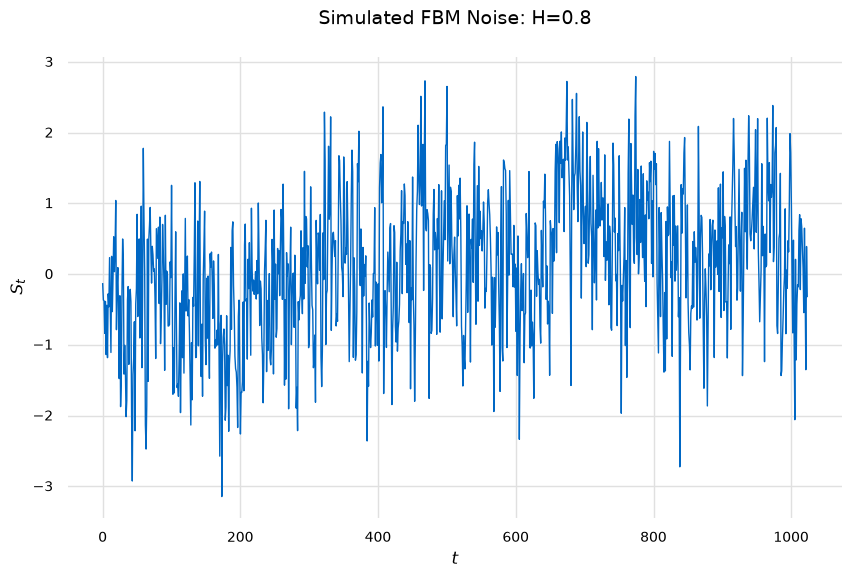

In [3]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

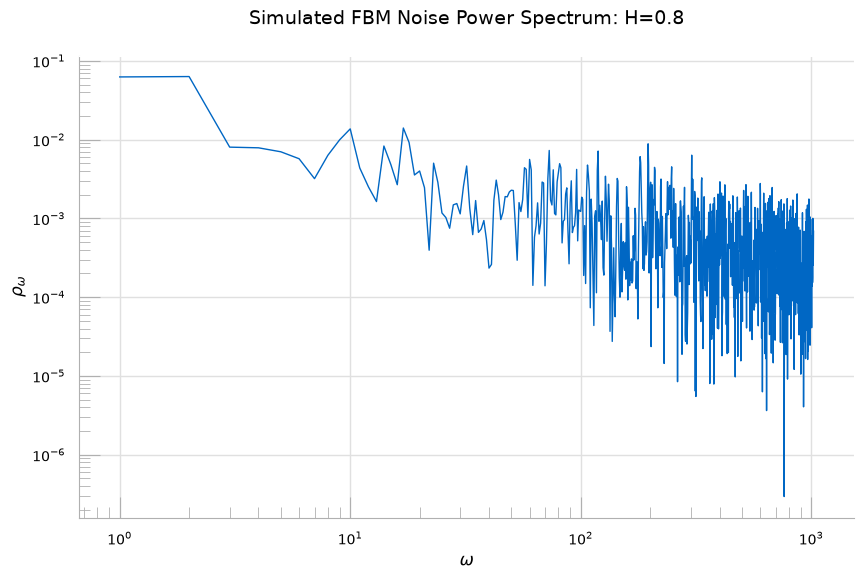

In [4]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [5]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     261.4
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.63e-52
Time:                        11:45:58   Log-Likelihood:                -808.67
No. Observations:                1023   AIC:                             1621.
Df Residuals:                    1021   BIC:                             1631.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7754      0.102    -17.416      0.000      -1.975      -1.575
x1            -0.6307      0.039    -16.166      0.000      -0.707      -0.554
==============================================================================
Omnibus:                      117.928   Durbin-Watson:                   1.390
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              173.615
Skew:                          -0.827   Prob(JB):                     2.00e-38
Kurtosis:                       4.156   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [6]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -1.7753603834054226,
      "err": 0.10193618256539788,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "536931f9-c196-4ddb-8433-93ed343ea4ae",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.6307372762494723,
         "err": 0.039015399560553686,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "536931f9-c196-4ddb-8433-93ed343ea4ae",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.20380640047420695,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "536931f9-c196-4ddb-8433-93ed343ea4ae",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param"

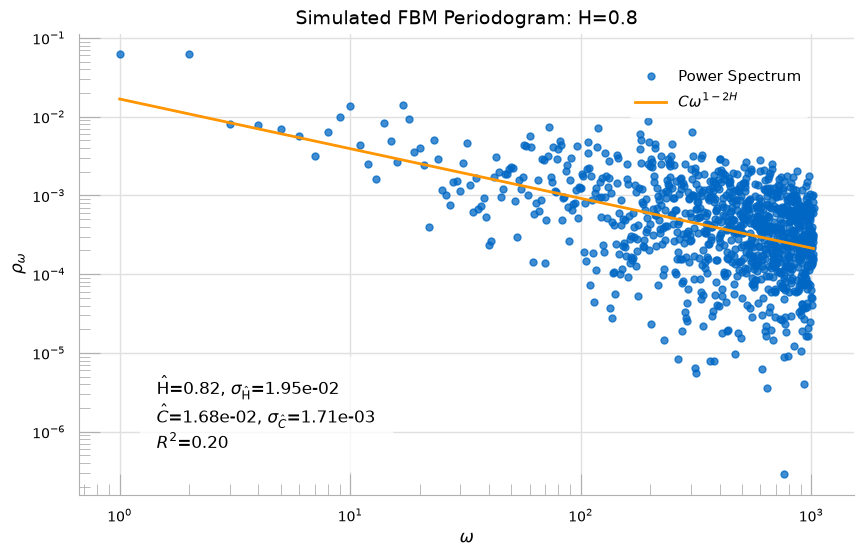

In [7]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.3

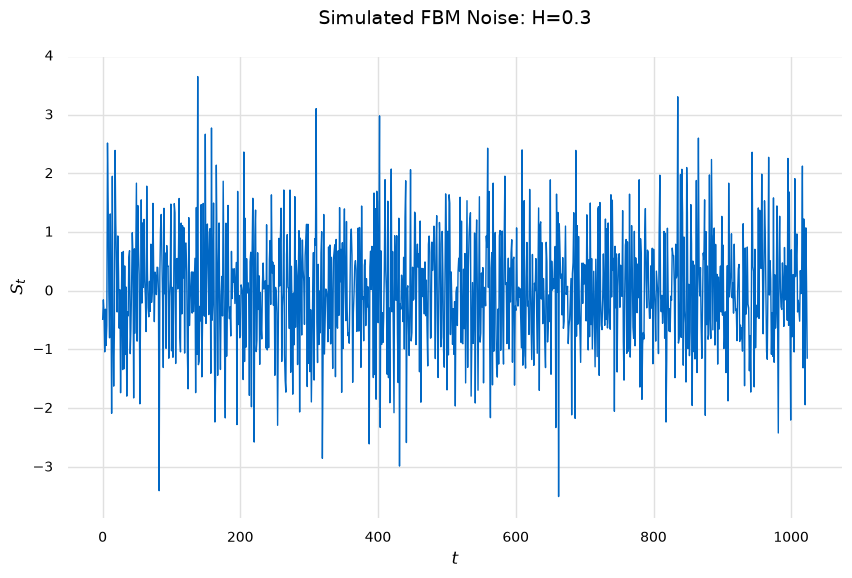

In [8]:
H = 0.3
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

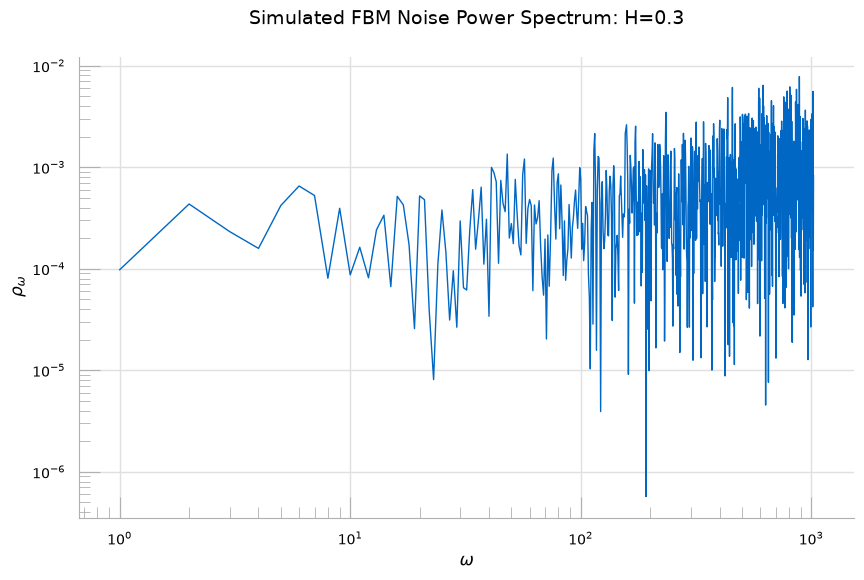

In [9]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [10]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     102.6
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           4.87e-23
Time:                        11:45:58   Log-Likelihood:                -812.39
No. Observations:                1023   AIC:                             1629.
Df Residuals:                    1021   BIC:                             1639.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2971      0.102    -42.001      0.000      -4.498      -4.096
x1             0.3966      0.039     10.128      0.000       0.320       0.473
==============================================================================
Omnibus:                      172.343   Durbin-Watson:                   1.523
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              297.878
Skew:                          -1.052   Prob(JB):                     2.07e-65
Kurtosis:                       4.601   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -4.297076836973993,
      "err": 0.10230776656272567,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "ff33e880-0a3e-441c-8214-1bfa85d2fe71",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.3965947890249222,
         "err": 0.03915762087747176,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "ff33e880-0a3e-441c-8214-1bfa85d2fe71",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.09129721499689258,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "ff33e880-0a3e-441c-8214-1bfa85d2fe71",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param": {

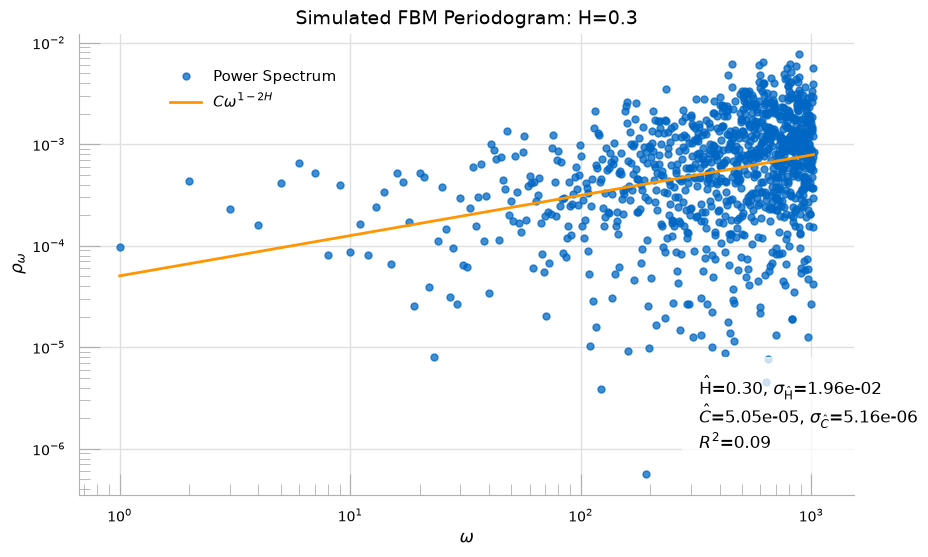

In [12]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.95

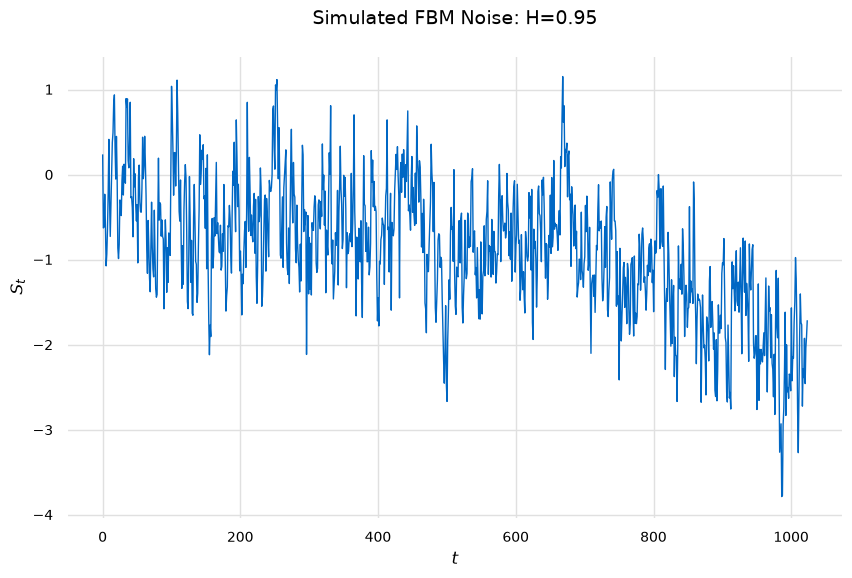

In [13]:
H = 0.95
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

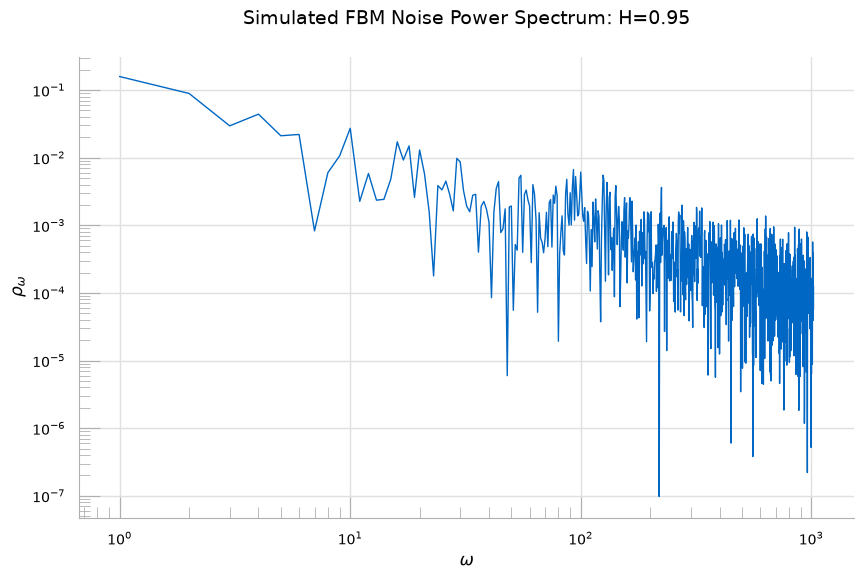

In [14]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [15]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     642.4
Date:                Sun, 30 Aug 2026   Prob (F-statistic):          2.50e-110
Time:                        11:45:58   Log-Likelihood:                -849.38
No. Observations:                1023   AIC:                             1703.
Df Residuals:                    1021   BIC:                             1713.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0267      0.106     -9.679      0.000      -1.235      -0.819
x1            -1.0290      0.041    -25.345      0.000      -1.109      -0.949
==============================================================================
Omnibus:                      255.196   Durbin-Watson:                   1.428
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              727.223
Skew:                          -1.254   Prob(JB):                    1.22e-158
Kurtosis:                       6.282   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -1.026724966489672,
      "err": 0.10607452023492274,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "83f0ab31-832f-4d93-85af-6bd26777dd7a",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.028979084490861,
         "err": 0.04059932092811538,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "83f0ab31-832f-4d93-85af-6bd26777dd7a",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.3861805839388317,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "83f0ab31-832f-4d93-85af-6bd26777dd7a",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param": {


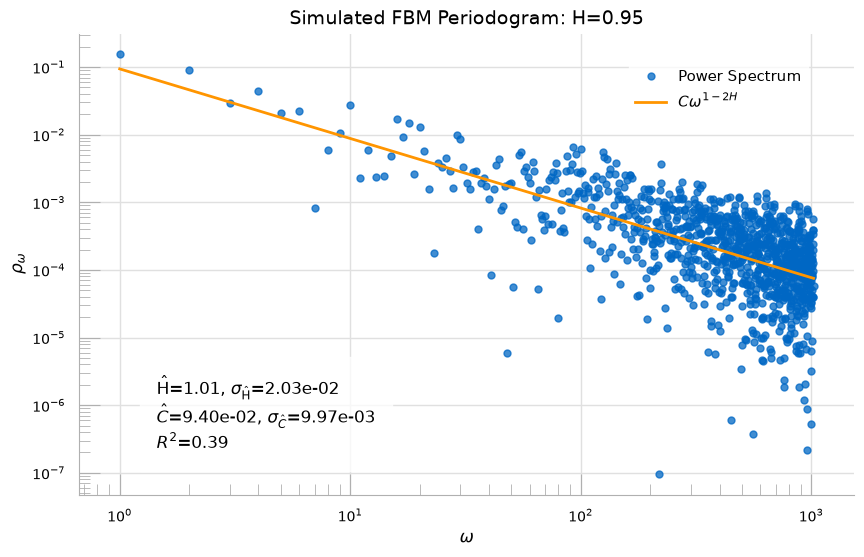

In [17]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")